In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving sign_mnist_train.csv to sign_mnist_train.csv


In [ ]:
train_data = pd.read_csv("sign_mnist_train.csv")

In [ ]:
total_samples = train_data.shape[0]
print("Number of training images:", total_samples)

Number of training images: 27455


In [ ]:


y = train_data.iloc[:, 0].values
X = train_data.iloc[:, 1:].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (27455, 784)
y shape: (27455,)


In [ ]:
# Randomly select 500 indices
indices = np.random.choice(total_samples, 6000, replace=False)

# Create reduced dataset
X = X[indices]
y = y[indices]

In [ ]:
X.shape

(6000, 784)

In [ ]:
X = X / 255.0
X = X.reshape(-1, 28, 28)

print("Final shape:", X.shape)

Final shape: (6000, 28, 28)


In [ ]:
unique_labels = sorted(np.unique(y))
label_map = {old: new for new, old in enumerate(unique_labels)}

y = np.array([label_map[label] for label in y])

print("Max label:", np.max(y))  # MUST be 23

Max label: 23


In [ ]:
X_train = X[:400]
y_train = y[:400]

X_val = X[400:]
y_val = y[400:]

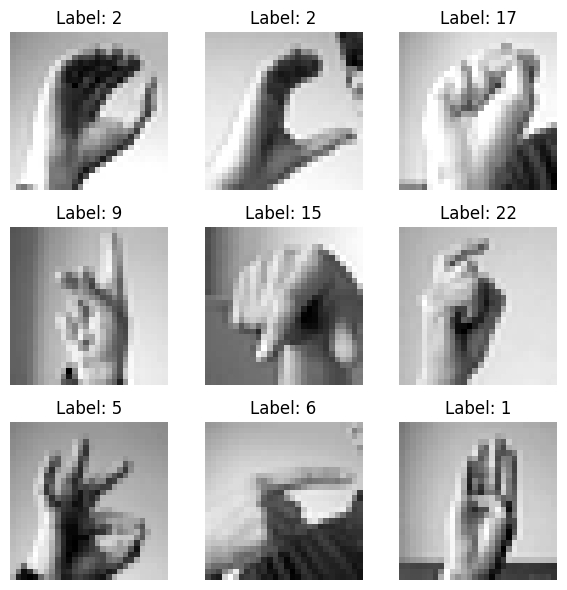

In [ ]:
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X[i], cmap='gray')
    plt.title("Label: " + str(y[i]))
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
filter_size = 3
num_filters = 6
pool_size = 2
learning_rate = 0.01
output_size = 24

# Initialize convolution filters
filters = np.random.randn(num_filters, filter_size, filter_size) * 0.1

# Automatically compute output size
image_size = 28
conv_output_size = image_size - filter_size + 1
pool_output_size = conv_output_size // pool_size


input_size = pool_output_size * pool_output_size * num_filters
# Initialize dense layer
hidden_size = 64

# First dense layer
W1 = np.random.randn(input_size, hidden_size) * 0.1
b1 = np.zeros(hidden_size)

# Output layer
W2 = np.random.randn(hidden_size, output_size) * 0.1
b2 = np.zeros(output_size)

In [ ]:
print("convolution output size:",conv_output_size)
print("pooling output size:",pool_output_size)
print("input size",input_size)
print("output size",output_size)
print("initial weights",weights)
print("initial bias",bias)
print("initial filters",filters)

convolution output size: 26
pooling output size: 13
input size 1014
output size 24
initial weights [[-0.122494    0.02102971  0.01496934 ...  0.05780469  0.00316157
  -0.03748306]
 [-0.09609606 -0.10122391  0.11263365 ...  0.13375992  0.12147697
   0.13181516]
 [ 0.1134953  -0.18535557 -0.07940137 ...  0.06098881 -0.2332617
  -0.09813634]
 ...
 [-0.0763875  -0.14532836 -0.22390628 ... -0.11931406 -0.0183821
   0.05177247]
 [ 0.0259346  -0.03472046 -0.07115282 ...  0.18484519 -0.02826623
  -0.03022675]
 [ 0.1803994   0.02440249  0.07093153 ... -0.11304135  0.2161349
  -0.03424168]]
initial bias [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
initial filters [[[ 0.04967142 -0.01382643  0.06476885]
  [ 0.15230299 -0.02341534 -0.0234137 ]
  [ 0.15792128  0.07674347 -0.04694744]]

 [[ 0.054256   -0.04634177 -0.04657298]
  [ 0.02419623 -0.19132802 -0.17249178]
  [-0.05622875 -0.10128311  0.03142473]]

 [[-0.09080241 -0.14123037  0.14656488]
  [-0.02257763  0.0067528

In [ ]:
print("Num filters:", num_filters)
print("Pool output size:", pool_output_size)
print("Expected input size:", pool_output_size * pool_output_size * num_filters)

Num filters: 6
Pool output size: 13
Expected input size: 1014


In [ ]:
print("Weights shape:", W1.shape)

Weights shape: (1014, 64)


SINCE

In [ ]:
def convolution(image, filter):
    h, w = image.shape
    f = filter.shape[0]
    output = np.zeros((h - f + 1, w - f + 1))

    for i in range(output.shape[0]):
        for j in range(output.shape[1]):
            region = image[i:i+f, j:j+f]
            output[i, j] = np.sum(region * filter)

    return output

activation function: ReLu

In [ ]:
def relu(x):
    return np.maximum(0, x)

POOLING LAYER:MAX POOLING

In [ ]:
def maxpool(image, size=2):
    h, w = image.shape
    output = np.zeros((h//size, w//size))

    for i in range(0, h, size):
        for j in range(0, w, size):
            region = image[i:i+size, j:j+size]
            output[i//size, j//size] = np.max(region)

    return output

FLATTENING LAYER:

In [ ]:
def flatten(image):
    return image.flatten()

BACKPROPOGATION:

In [ ]:
# softmax+cross entropy loss

def softmax_backward(pred, label):
    grad = pred.copy()
    grad[label] -= 1
    return grad

In [ ]:
#dense backward

def dense_backward(dZ, X, weights):
    dW = np.outer(X, dZ)
    db = dZ
    dX = np.dot(weights, dZ)
    return dW, db, dX

In [ ]:
#relu backward

def relu_backward(dA, Z):
    dZ = dA.copy()
    dZ[Z <= 0] = 0
    return dZ

In [ ]:
#maxpool backward

def maxpool_backward(dpool, relu_out, size=2):
    h, w = relu_out.shape
    d_relu = np.zeros_like(relu_out)

    for i in range(h//size):
        for j in range(w//size):
            region = relu_out[i*size:(i+1)*size,
                              j*size:(j+1)*size]
            max_val = np.max(region)

            for x in range(size):
                for y in range(size):
                    if region[x,y] == max_val:
                        d_relu[i*size+x, j*size+y] = dpool[i,j]

    return d_relu

In [ ]:
#convolution backward

def conv_backward(dconv, image, filter):
    f = filter.shape[0]
    dfilter = np.zeros_like(filter)

    for i in range(dconv.shape[0]):
        for j in range(dconv.shape[1]):
            region = image[i:i+f, j:j+f]
            dfilter += dconv[i,j] * region

    return dfilter

TRAINING:

In [ ]:
best_weights = None
best_bias = None
best_filters = None
best_val_loss = float('inf')
best_epoch = 0

In [ ]:
# ---------- STORE INITIAL PARAMETERS ----------
initial_W1 = W1.copy()
initial_b1 = b1.copy()
initial_W2 = W2.copy()
initial_b2 = b2.copy()
initial_filters = filters.copy()

best_W1 = None
best_b1 = None
best_W2 = None
best_b2 = None
best_filters = None

best_val_loss = float('inf')
best_epoch = 0

train_loss_history = []
val_loss_history = []

epochs = 10
learning_rate = 0.001
lambda_reg = 0.0005

for epoch in range(epochs):

    total_train_loss = 0

    # -------- TRAINING --------
    for i in range(len(X_train)):

        image = X_train[i]
        label = y_train[i]

        # -------- FORWARD --------

        conv_out = np.zeros((26, 26, num_filters))
        for f in range(num_filters):
            conv_out[:, :, f] = convolution(image, filters[f])

        relu_out = relu(conv_out)

        pool_out = np.zeros((13, 13, num_filters))
        for f in range(num_filters):
            pool_out[:, :, f] = maxpool(relu_out[:, :, f])

        flat = flatten(pool_out)

        # Dense 1
        z1 = np.dot(flat, W1) + b1
        a1 = relu(z1)

        # Dense 2
        z2 = np.dot(a1, W2) + b2
        pred = softmax(z2)

        loss = -np.log(pred[label])
        total_train_loss += loss

        # -------- BACKWARD --------

        # Output layer
        dZ2 = softmax_backward(pred, label)
        dW2 = np.outer(a1, dZ2)
        db2 = dZ2
        da1 = np.dot(W2, dZ2)

        # Hidden layer
        dz1 = da1 * (z1 > 0)
        dW1 = np.outer(flat, dz1)
        db1 = dz1
        dflat = np.dot(W1, dz1)

        # -------- CONV BACKWARD --------

        dpool = dflat.reshape(pool_out.shape)

        drelu = np.zeros_like(relu_out)
        dfilter = np.zeros_like(filters)

        for f in range(num_filters):

            drelu[:, :, f] = maxpool_backward(
                dpool[:, :, f], relu_out[:, :, f], pool_size
            )

            dconv = relu_backward(drelu[:, :, f], conv_out[:, :, f])

            dfilter[f] = conv_backward(dconv, image, filters[f])

        # -------- UPDATE --------

        W2 -= learning_rate * (dW2 + lambda_reg * W2)
        b2 -= learning_rate * db2

        W1 -= learning_rate * (dW1 + lambda_reg * W1)
        b1 -= learning_rate * db1

        filters -= learning_rate * (dfilter + lambda_reg * filters)

    # -------- TRAIN LOSS --------
    avg_train_loss = total_train_loss / len(X_train)
    train_loss_history.append(avg_train_loss)

    # -------- VALIDATION --------
    total_val_loss = 0
    correct = 0

    for i in range(len(X_val)):

        image = X_val[i]
        label = y_val[i]

        conv_out = np.zeros((26, 26, num_filters))
        for f in range(num_filters):
            conv_out[:, :, f] = convolution(image, filters[f])

        relu_out = relu(conv_out)

        pool_out = np.zeros((13, 13, num_filters))
        for f in range(num_filters):
            pool_out[:, :, f] = maxpool(relu_out[:, :, f])

        flat = flatten(pool_out)

        z1 = np.dot(flat, W1) + b1
        a1 = relu(z1)

        z2 = np.dot(a1, W2) + b2
        pred = softmax(z2)

        loss = -np.log(pred[label])
        total_val_loss += loss

        if np.argmax(pred) == label:
            correct += 1

    avg_val_loss = total_val_loss / len(X_val)
    val_accuracy = correct / len(X_val)

    val_loss_history.append(avg_val_loss)

    print("\n==============================")
    print(f"Epoch {epoch+1}")
    print("Train Loss:", avg_train_loss)
    print("Val Loss:", avg_val_loss)
    print("Val Accuracy:", val_accuracy)

    # -------- SAVE BEST MODEL --------
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1

        best_W1 = W1.copy()
        best_b1 = b1.copy()
        best_W2 = W2.copy()
        best_b2 = b2.copy()
        best_filters = filters.copy()

print("\nBest Epoch:", best_epoch)

# -------- LOAD BEST MODEL --------
W1 = best_W1
b1 = best_b1
W2 = best_W2
b2 = best_b2
filters = best_filters


Epoch 1
Train Loss: 3.1730206460222212
Val Loss: 3.1757131630896773
Val Accuracy: 0.045892857142857145

Epoch 2
Train Loss: 3.171881047193358
Val Loss: 3.1760383705298993
Val Accuracy: 0.054642857142857146

Epoch 3
Train Loss: 3.170259415515904
Val Loss: 3.175584735028154
Val Accuracy: 0.05964285714285714

Epoch 4
Train Loss: 3.1687167241618375
Val Loss: 3.1752010146185943
Val Accuracy: 0.06535714285714286

Epoch 5
Train Loss: 3.167313080460713
Val Loss: 3.1748201288010627
Val Accuracy: 0.06625

Epoch 6
Train Loss: 3.165908936203519
Val Loss: 3.174520777528573
Val Accuracy: 0.06625

Epoch 7
Train Loss: 3.1645857281797047
Val Loss: 3.1741124385640775
Val Accuracy: 0.06553571428571428

Epoch 8
Train Loss: 3.163274740183462
Val Loss: 3.1737385002101095
Val Accuracy: 0.06642857142857143

Epoch 9
Train Loss: 3.1619470466748028
Val Loss: 3.1733671126005447
Val Accuracy: 0.06678571428571428

Epoch 10
Train Loss: 3.1605629784595366
Val Loss: 3.1729956105337362
Val Accuracy: 0.06625

Best Epoc

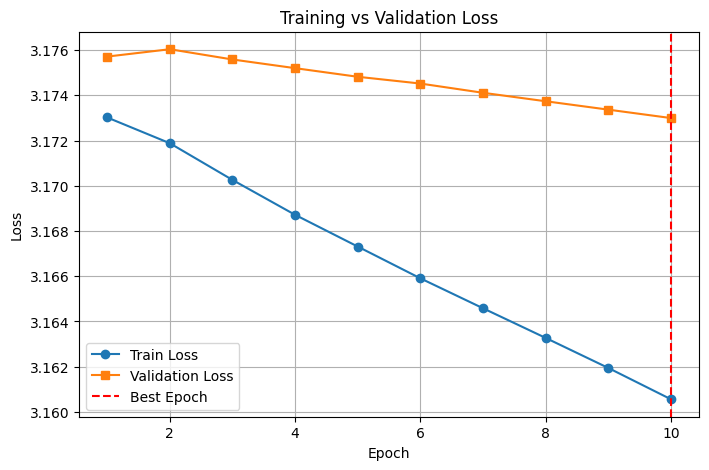

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

epochs_range = range(1, len(train_loss_history)+1)

plt.plot(epochs_range, train_loss_history, marker='o', label="Train Loss")
plt.plot(epochs_range, val_loss_history, marker='s', label="Validation Loss")
plt.axvline(best_epoch, color='r', linestyle='--', label="Best Epoch")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
weights = best_weights
bias = best_bias
filters = best_filters

TESTING DATA

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving sign_mnist_test.csv to sign_mnist_test (1).csv


In [ ]:
import pandas as pd
import numpy as np

test_data = pd.read_csv("sign_mnist_test.csv").values

y_test = test_data[:, 0]
X_test = test_data[:, 1:]

print("Test data shape:", X_test.shape)

Test data shape: (7172, 784)


In [ ]:
import pandas as pd
import numpy as np

test_data = pd.read_csv("sign_mnist_test.csv").values

y_test_raw = test_data[:, 0]
X_test = test_data[:, 1:]

print("Original test shape:", X_test.shape)

Original test shape: (7172, 784)


In [ ]:
X_test = X_test / 255.0
X_test = X_test.reshape(-1, 28, 28)

print("Reshaped test shape:", X_test.shape)
print("Single image shape:", X_test[0].shape)

Reshaped test shape: (7172, 28, 28)
Single image shape: (28, 28)


In [ ]:
correct = 0
total = 0

for i in range(len(X_test)):

    if y_test[i] == -1:
        continue

    image = X_test[i]
    label = y_test[i]

    # -------- FORWARD --------

    # Multi-filter convolution
    conv_out = np.zeros((26, 26, num_filters))
    for f in range(num_filters):
        conv_out[:, :, f] = convolution(image, filters[f])

    relu_out = relu(conv_out)

    # Pooling
    pool_out = np.zeros((13, 13, num_filters))
    for f in range(num_filters):
        pool_out[:, :, f] = maxpool(relu_out[:, :, f], pool_size)

    flat = flatten(pool_out)

    # Dense layer 1
    z1 = np.dot(flat, W1) + b1
    a1 = relu(z1)

    # Dense layer 2
    z2 = np.dot(a1, W2) + b2
    pred = softmax(z2)

    predicted_label = np.argmax(pred)

    if predicted_label == label:
        correct += 1

    total += 1

accuracy = correct / total
print("Test Accuracy:", accuracy)

Test Accuracy: 0.07348020078081428


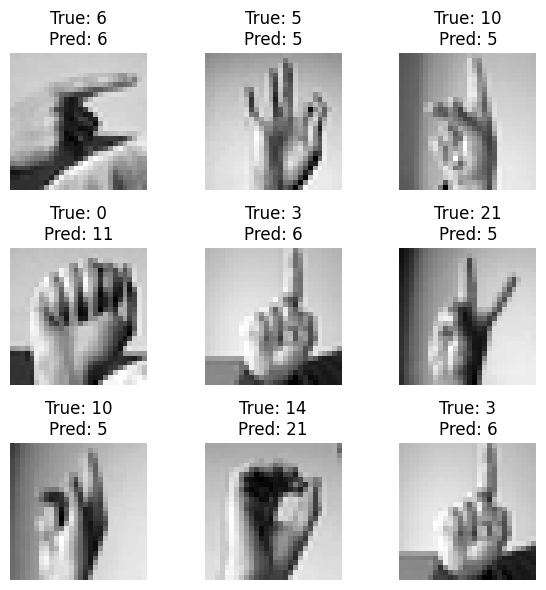

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

shown = 0
i = 0

while shown < 9 and i < len(X_test):

    if y_test[i] == -1:
        i += 1
        continue

    image = X_test[i]
    label = y_test[i]

    # -------- FORWARD PASS --------

    # Multi-filter convolution
    conv_out = np.zeros((26, 26, num_filters))
    for f in range(num_filters):
        conv_out[:, :, f] = convolution(image, filters[f])

    relu_out = relu(conv_out)

    # Pooling
    pool_out = np.zeros((13, 13, num_filters))
    for f in range(num_filters):
        pool_out[:, :, f] = maxpool(relu_out[:, :, f], pool_size)

    flat = flatten(pool_out)

    # Dense layer 1
    z1 = np.dot(flat, W1) + b1
    a1 = relu(z1)

    # Dense layer 2
    z2 = np.dot(a1, W2) + b2
    pred = softmax(z2)

    predicted_label = np.argmax(pred)

    # -------- PLOT --------

    plt.subplot(3,3,shown+1)
    plt.imshow(image, cmap='gray')
    plt.title(f"True: {label}\nPred: {predicted_label}")
    plt.axis("off")

    shown += 1
    i += 1

plt.tight_layout()
plt.show()

the testing and training accuracies are very very low due to the the entire dataset is not taken into consideration and also it is done from scratch running the epochs takes lots of time without gpu
also it can be due to the type of filters and the number of filters used , how much the layer is dense etc